In [3]:
import sys
import os
sys.path.append("..")

import pandas as pd
import numpy as np

from src.data_preprocessing import LoanDataPreprocessor
from src.data_split import split_data
from src.woe_binning import WoeBinner
from src.config import DISCRETE_VARS
from src.config import CONTINUOUS_VARS
from src.config import BIN_RULES
from src.feature_engineering import apply_feature_engineering
from src.pd_model import PDModel
from src.data_validation import validate_input

In [4]:
from src.model_evaluation import ModelEvaluation
import matplotlib.pyplot as plt

In [5]:
pd.options.display.max_columns=None
pd.options.display.max_rows=100

In [6]:
data_processor=LoanDataPreprocessor()

INFO:root:Preprocessing version: v1.0


In [7]:
df=data_processor.preprocess('../data/loan_data_2007_2014.csv')

INFO:root:Cleaning employment length
INFO:root:Cleaning term
INFO:root:dates conversion
INFO:root:credit age creation
INFO:root:missing values handling
INFO:root:target variable creation
INFO:root:Applying outlier capping on 33 columns
INFO:root:final dataset shape: (466285, 81)


In [8]:
data_processor.validate_target(df)


===== TARGET VALIDATION =====

Configured BAD_STATUS values:
 - Charged Off
 - Default
 - Does not meet the credit policy. Status:Charged Off
 - Late (31-120 days)

Component Breakdown:
 loan_status
Charged Off                                            42475
Late (31-120 days)                                      6900
Default                                                  832
Does not meet the credit policy. Status:Charged Off      761
Name: count, dtype: int64

Total Bad Count: 50968
Sum of Components: 50968

✅ VALIDATION PASSED


In [9]:
df['loan_status'].value_counts()

loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64

In [10]:
df.head(3)

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,emp_length_int,term_int,earliest_cr_line_date,credit_age_months,loan_status_clean,good_bad
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,0,10+ years,RENT,24000.0,Verified,2011-12-01,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-85,1.0,0.0,0.0,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.0,0.00,0.00,Jan-15,171.62,0,Jan-16,0.0,0.0,1,INDIVIDUAL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5000.0,0.0,0.0,0.0,10.0,36,1985-01-01,327,Fully Paid,0
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,2011-12-01,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-99,5.0,0.0,0.0,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.0,117.08,1.11,Apr-13,119.66,0,Sep-13,0.0,0.0,1,INDIVIDUAL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2500.0,0.0,0.0,0.0,0.0,60,1999-04-01,154,Charged Off,1
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,0,10+ years,RENT,12252.0,Not Verified,2011-12-01,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,0,small_business,real estate business,606xx,IL,8.72,0.0,Nov-01,2.0,0.0,0.0,2.0,0.0,2956,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.0,0.00,0.00,Jun-14,649.91,0,Jan-16,0.0,0.0,1,INDIVIDUAL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2400.0,0.0,0.0,0.0,10.0,36,2001-11-01,122,Fully Paid,0


In [11]:
df.isnull().sum()

Unnamed: 0                     0
id                             0
member_id                      0
loan_amnt                      0
funded_amnt                    0
funded_amnt_inv                0
term                           0
int_rate                       0
installment                    0
grade                          0
sub_grade                      0
emp_title                      0
emp_length                     0
home_ownership                 0
annual_inc                     0
verification_status            0
issue_d                        0
loan_status                    0
pymnt_plan                     0
url                            0
desc                           0
purpose                        0
title                          0
zip_code                       0
addr_state                     0
dti                            0
delinq_2yrs                    0
earliest_cr_line               0
inq_last_6mths                 0
mths_since_last_delinq         0
mths_since

In [12]:
validate_input(df)

True

In [13]:
train_df,test_df=split_data(df)

In [14]:
print(train_df.shape, test_df.shape)


(373028, 81) (93257, 81)


In [15]:
X_train = train_df.drop(columns=['good_bad'])
y_train = train_df['good_bad']


In [16]:
X_test = test_df.drop(columns=['good_bad'])
y_test = test_df['good_bad']

In [17]:
train_df, feature_cols=apply_feature_engineering(train_df,None)

INFO:root:Starting feature engineering
INFO:root:Applying categorical grouping
INFO:root:Feature engineering completed. Shape: (373028, 86)
INFO:root:Feature engineering version: v1.0


In [18]:
test_df,_=apply_feature_engineering(test_df,None)

INFO:root:Starting feature engineering
INFO:root:Applying categorical grouping
INFO:root:Feature engineering completed. Shape: (93257, 86)
INFO:root:Feature engineering version: v1.0


In [19]:
train_df.head(3)

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,emp_length_int,term_int,earliest_cr_line_date,credit_age_months,loan_status_clean,good_bad,home_ownership_grp,purpose_grp,addr_state_grp,mths_since_last_delinq_missing,mths_since_last_record_missing
106734,106734,586040,752920,19200,19200,19200.0,36 months,6.03,584.37,A,A1,Morgan Stanley,5 years,MORTGAGE,85000.0,Verified,2013-08-01,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 07/30/13 > The loan is for...,debt_consolidation,Credit Debt,070xx,NJ,8.26,0.0,Feb-98,0.0,0.0,0.0,11.0,0.0,31076,52.5,20.0,w,0.00,0.00,20442.46936,20442.47,19200.00,1242.47,0.0,0.0,0.0,Dec-14,11676.92,0,Jan-16,0.0,0.0,1,INDIVIDUAL,0.0,0.0,0.0,0.0,0.0,379491.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,59162.0,0.0,0.0,0.0,5.0,36,1998-02-01,188,Fully Paid,0,MORTGAGE,medium_risk,MEDIUM_RISK,0,0
183573,183573,2214837,2626993,24500,24500,24475.0,60 months,22.47,683.23,E,E5,Computer Sciences Corporation,10+ years,MORTGAGE,110000.0,Verified,2012-11-01,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 11/21/12 > This is a debt ...,debt_consolidation,Consolidation Loan,762xx,TX,19.17,1.0,Sep-93,3.0,12.0,0.0,12.0,0.0,17599,64.5,36.0,w,0.00,0.00,29877.53141,29847.08,24500.00,5377.53,0.0,0.0,0.0,Apr-14,670.65,0,Jan-16,0.0,0.0,1,INDIVIDUAL,0.0,0.0,0.0,0.0,0.0,249672.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,27300.0,0.0,0.0,0.0,10.0,60,1993-09-01,233,Fully Paid,0,MORTGAGE,medium_risk,LOW_RISK,0,0
52853,52853,9394616,11226763,6400,6400,6400.0,36 months,8.90,203.23,A,A5,IT Specialist,9 years,MORTGAGE,110700.0,Not Verified,2013-12-01,Current,n,https://www.lendingclub.com/browse/loanDetail....,0,debt_consolidation,Tuition,117xx,NY,19.02,2.0,Nov-98,0.0,15.0,0.0,8.0,0.0,4070,50.9,42.0,w,2138.81,2138.81,5080.75000,5080.75,4261.19,819.56,0.0,0.0,0.0,Jan-16,203.23,Feb-16,Jan-16,0.0,0.0,1,INDIVIDUAL,0.0,0.0,0.0,0.0,0.0,231381.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8000.0,0.0,0.0,0.0,9.0,36,1998-11-01,183,Current,0,MORTGAGE,medium_risk,HIGH_RISK,0,0


In [20]:
X_train = train_df.drop(columns=['good_bad'])
y_train = train_df['good_bad']

In [21]:
woe=WoeBinner()

In [22]:
for var, bins in BIN_RULES.items():
    woe.set_bin_rules(var, bins)

In [23]:
train_df=woe.apply_bins(train_df)
test_df=woe.apply_bins(test_df)

In [24]:
print("Checking bin columns...")

for var in BIN_RULES.keys():
    col = f"{var}_bin"
    if col in train_df.columns:
        print(f"✔ {col} exists")
    else:
        print(f"❌ {col} MISSING")

Checking bin columns...
✔ int_rate_bin exists
✔ dti_bin exists
✔ annual_inc_bin exists
✔ installment_bin exists
✔ delinq_2yrs_bin exists
✔ inq_last_6mths_bin exists
✔ credit_age_months_bin exists
✔ open_acc_bin exists
✔ total_acc_bin exists


In [25]:
missing_cont = {f"{var}_bin" for var in BIN_RULES.keys()} - set(train_df.columns)
if missing_cont:
    raise ValueError(f'Missing continuous variables: {missing_cont}')

missing_disc=set(DISCRETE_VARS)-set(X_train.columns)
if missing_disc:
    raise ValueError(f'Missing discrete variables: {missing_disc}')

In [26]:
binned_vars=[f'{var}_bin' for var in BIN_RULES.keys()]
ALL_DISCRETE_VARS=DISCRETE_VARS+binned_vars

In [27]:
print('Missing variables:', [v for v in ALL_DISCRETE_VARS if v not in train_df.columns])

Missing variables: []


In [28]:
woe.fit(train_df, y_train, discrete_vars=ALL_DISCRETE_VARS)

In [29]:
train_df=woe.transform(train_df)
test_df=woe.transform(test_df)

In [30]:
train_df.columns

Index(['Unnamed: 0', 'id', 'member_id', 'loan_amnt', 'funded_amnt',
       'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade',
       ...
       'initial_list_status_woe', 'int_rate_bin_woe', 'dti_bin_woe',
       'annual_inc_bin_woe', 'installment_bin_woe', 'delinq_2yrs_bin_woe',
       'inq_last_6mths_bin_woe', 'credit_age_months_bin_woe',
       'open_acc_bin_woe', 'total_acc_bin_woe'],
      dtype='object', length=110)

In [31]:
train_df.shape

(373028, 110)

In [32]:
[c for c in train_df.columns if '_woe' in c]

['grade_woe',
 'home_ownership_woe',
 'addr_state_woe',
 'verification_status_woe',
 'purpose_woe',
 'initial_list_status_woe',
 'int_rate_bin_woe',
 'dti_bin_woe',
 'annual_inc_bin_woe',
 'installment_bin_woe',
 'delinq_2yrs_bin_woe',
 'inq_last_6mths_bin_woe',
 'credit_age_months_bin_woe',
 'open_acc_bin_woe',
 'total_acc_bin_woe']

In [33]:
X_train_woe=train_df.filter(like='_woe')
X_test_woe=test_df.filter(like='_woe')

In [34]:
y_train=train_df['good_bad']
y_test=test_df['good_bad']

In [35]:
iv_df=woe.iv_summary()
iv_threshold=0.02

In [36]:
iv_df

,Variable,IV
6,int_rate_bin,0.313730
0,grade,0.294955
11,inq_last_6mths_bin,0.046127
8,annual_inc_bin,0.044653
4,purpose,0.038088
12,credit_age_months_bin,0.026986
7,dti_bin,0.024887
5,initial_list_status,0.023626
1,home_ownership,0.022414
3,verification_status,0.021374


In [37]:
selected_vars=iv_df[iv_df['IV']>=iv_threshold]['Variable'].tolist()
selected_woe_vars = [var + '_woe' for var in selected_vars]

In [38]:
selected_woe_vars

['int_rate_bin_woe',
 'grade_woe',
 'inq_last_6mths_bin_woe',
 'annual_inc_bin_woe',
 'purpose_woe',
 'credit_age_months_bin_woe',
 'dti_bin_woe',
 'initial_list_status_woe',
 'home_ownership_woe',
 'verification_status_woe']

In [39]:
X_train=X_train_woe[selected_woe_vars]
X_test=X_test_woe[selected_woe_vars]

In [40]:
set(selected_woe_vars)-set(X_train_woe.columns)

set()

In [41]:
print([v for v in selected_woe_vars if v not in train_df.columns])

[]


In [42]:
corr_matrix=X_train.corr().abs()
threshold = 0.7
'''
upper=corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop=[col for col in upper.columns if any(upper[col]>0.7)]
'''


'\nupper=corr_matrix.where(\n    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))\nto_drop=[col for col in upper.columns if any(upper[col]>0.7)]\n'

In [43]:
corr_pairs = []


for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

print("Highly correlated pairs:")
for pair in corr_pairs:
    print(pair)

Highly correlated pairs:
('grade_woe', 'int_rate_bin_woe', np.float64(0.9264726566301066))


Grade and interest rate showed very high correlation (~0.92), since interest rate is largely determined using grade and internal pricing policy.

Although interest rate had slightly higher IV, grade was retained because it is more interpretable, governance-friendly, and avoids potential policy leakage.

In [44]:
manual_drop = [
    'int_rate_bin_woe'
]

In [45]:
auto_drop = []

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

auto_drop = [col for col in upper.columns if any(upper[col] > threshold)]

In [46]:
to_drop=manual_drop if manual_drop else auto_drop
print('Final columns to drop', to_drop)

Final columns to drop ['int_rate_bin_woe']


In [47]:

X_train=X_train.drop(columns=to_drop, errors='ignore')
X_test=X_test.drop(columns=to_drop,errors='ignore')

In [48]:
X_train.columns

Index(['grade_woe', 'inq_last_6mths_bin_woe', 'annual_inc_bin_woe',
       'purpose_woe', 'credit_age_months_bin_woe', 'dti_bin_woe',
       'initial_list_status_woe', 'home_ownership_woe',
       'verification_status_woe'],
      dtype='object')

In [49]:
assert X_train.shape[1] == X_test.shape[1], "Train-Test feature mismatch"

In [50]:
assert list(X_train.columns) == list(X_test.columns), "Column order mismatch"

In [51]:
print(f"Dropped {len(to_drop)} correlated features")

Dropped 1 correlated features


In [52]:
pd_model=PDModel()

In [53]:
pd_model.fit(X_train, y_train)

INFO:root:Training data shape : (373028, 9)
INFO:root:Training PD logistic regression model


In [54]:
y_pred_train = pd_model.predict_proba(X_train)
y_pred_test = pd_model.predict_proba(X_test)

INFO:root:Generating predictions
INFO:root:scoring data shape : (373028, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (93257, 10)


In [55]:
print(pd_model.summary())

                           Logit Regression Results                           
Dep. Variable:               good_bad   No. Observations:               373028
Model:                          Logit   Df Residuals:                   373018
Method:                           MLE   Df Model:                            9
Date:                Sun, 07 Jun 2026   Pseudo R-squ.:                 0.05427
Time:                        16:35:51   Log-Likelihood:            -1.2173e+05
converged:                       True   LL-Null:                   -1.2872e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -2.0999      0.006   -380.619      0.000      -2.111      -2.089
grade_woe                    -0.8538      0.011    -76.932      0.000      -0.876     

In [56]:
eval_model=ModelEvaluation()

In [57]:
auc_train = eval_model.auc(y_train, y_pred_train)
auc_test = eval_model.auc(y_test, y_pred_test)


In [58]:
print(f'AUC Train:{auc_train}')
print(f'AUC Test: {auc_test}')

AUC Train:0.673722985326187
AUC Test: 0.6711934516159


In [59]:
gini=eval_model.gini(y_test, y_pred_test)
print(f'GINI: {gini}')

GINI: 0.3423869032318001


In [60]:
ks_train=eval_model.ks(y_train, y_pred_train)
ks_test=eval_model.ks(y_test, y_pred_test)

print(f'KS Train:{ks_train}')
print(f'KS Test: {ks_test}')

KS Train:0.251673574943845
KS Test: 0.2495258633131836


Model Performance Summary:

- AUC ≈ 0.67 → moderate discrimination
- Gini ≈ 0.34 → acceptable predictive power
- KS ≈ 0.24 → moderate separation
- Train vs Test similar → no overfitting

In [61]:
FINAL_FEATURES=list(X_train.columns)

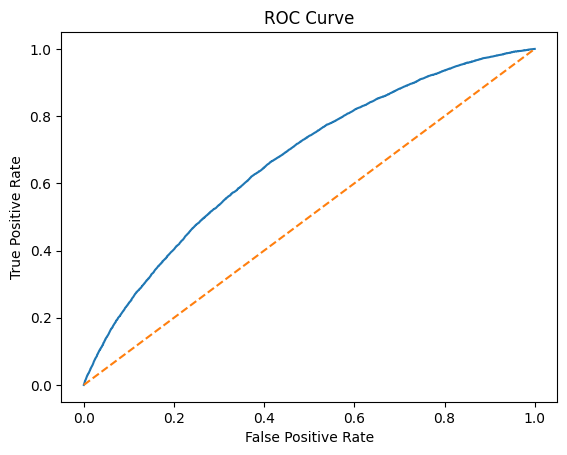

In [62]:
fpr, tpr, _ = eval_model.roc_curve_data(y_test, y_pred_test)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [63]:
df_ks=eval_model.ks_table(y_test, y_pred_test)
df_ks.head()

,y_true,y_pred,cum_bad,cum_good,diff
49918,0,0.479548,0.000000,0.000012,0.000012
41353,1,0.475044,0.000098,0.000012,0.000086
115316,0,0.461776,0.000098,0.000024,0.000074
416868,0,0.447121,0.000098,0.000036,0.000062
226840,1,0.445888,0.000196,0.000036,0.000160


In [64]:
df_ks['decile']=pd.qcut(df_ks['y_pred'],10, labels=False)
decile_table=df_ks.groupby('decile').agg({'y_true':['count','sum']})
decile_table.columns=['total', 'bads']
decile_table['goods']=decile_table['total']-decile_table['bads']
decile_table['bad_rate']=decile_table['bads']/decile_table['total']

decile_table=decile_table.sort_index(ascending=False)

decile_table


,total,bads,goods,bad_rate
decile,,,,
9,9326,2213,7113,0.237294
8,9314,1588,7726,0.170496
7,9332,1366,7966,0.146378
6,9324,1165,8159,0.124946
5,9332,986,8346,0.105658
4,9323,833,8490,0.089349
3,9313,694,8619,0.074519
2,9340,608,8732,0.065096
1,9327,471,8856,0.050499


In [65]:
PDO = 20
base_score = 600
base_odds = 7

factor = PDO / np.log(2)
offset = base_score - factor * np.log(1/base_odds)

In [66]:
import statsmodels.api as sm

def calculate_score(X, model, factor, offset):
    X=X.copy()
    X = sm.add_constant(X, has_constant='add')
    pd_pred=model.predict(X)
    pd_pred = np.clip(pd_pred, 1e-6, 1-1e-6)
    
   # Credit score formula
    score = offset + factor * np.log((1 - pd_pred) / pd_pred)

    return pd_pred, score

In [67]:
y_pred_train,train_scores = calculate_score(X_train, pd_model.model, factor, offset)
y_pred_test,test_scores = calculate_score(X_test, pd_model.model, factor, offset)

In [68]:
print(train_scores.head())
print('\n')
print(test_scores.head())

106734    761.977700
183573    706.618212
52853     762.454850
399347    720.788859
143199    705.699884
dtype: float64


159089    696.745045
204026    723.701983
446918    722.552087
309480    767.718253
427185    701.376743
dtype: float64


In [69]:
df_score=pd.DataFrame({'score': test_scores,'pd':y_pred_test})


In [70]:
df_score.head()

,score,pd
159089,696.745045,0.196705
204026,723.701983,0.087762
446918,722.552087,0.091005
309480,767.718253,0.020497
427185,701.376743,0.172567


In [71]:
def assign_band_pd(pd):
    if pd < 0.05:
        return "Very Low Risk"
    elif pd < 0.1:
        return "Low Risk"
    elif pd < 0.2:
        return "Medium Risk"
    elif pd < 0.35:
        return "High Risk"
    else:
        return "Very High Risk"

df_score['risk_band'] = df_score['pd'].apply(assign_band_pd)
df_score['score_bin']=pd.qcut(df_score['score'],10)

In [72]:
df_score.head()

,score,pd,risk_band,score_bin
159089,696.745045,0.196705,Medium Risk,"(658.508, 697.417]"
204026,723.701983,0.087762,Low Risk,"(720.202, 725.024]"
446918,722.552087,0.091005,Low Risk,"(720.202, 725.024]"
309480,767.718253,0.020497,Very Low Risk,"(748.635, 779.09]"
427185,701.376743,0.172567,Medium Risk,"(697.417, 704.875]"


In [73]:
df_score.describe()

,score,pd
count,93257.000000,93257.000000
mean,721.427334,0.109135
std,19.215133,0.061528
min,658.508950,0.013914
25%,707.829821,0.063208
50%,720.202219,0.097970
75%,733.938289,0.142927
max,779.090051,0.479548


In [74]:
band_summary = df_score.groupby('risk_band').agg({
    'score': ['count', 'mean', 'min', 'max'],
    'pd': ['mean', 'min', 'max']
})

In [75]:
print("\n===== BAND SUMMARY =====")
print(band_summary)


===== BAND SUMMARY =====
                score                                            pd            \
                count        mean         min         max      mean       min   
risk_band                                                                       
High Risk        7915  689.352132  674.014315  696.146611  0.241912  0.200003   
Low Risk        32908  728.874855  719.546160  741.105036  0.075704  0.050001   
Medium Risk     36917  709.204206  696.147595  719.545295  0.139356  0.100001   
Very High Risk    215  670.620003  658.508950  673.975434  0.377441  0.350263   
Very Low Risk   15302  752.204812  741.106700  779.090051  0.035673  0.013914   

                          
                     max  
risk_band                 
High Risk       0.349956  
Low Risk        0.099998  
Medium Risk     0.199997  
Very High Risk  0.479548  
Very Low Risk   0.049998  


In [76]:
print("\n===== SCORE SUMMARY =====")
print(df_score[['score', 'pd']].describe())


===== SCORE SUMMARY =====
              score            pd
count  93257.000000  93257.000000
mean     721.427334      0.109135
std       19.215133      0.061528
min      658.508950      0.013914
25%      707.829821      0.063208
50%      720.202219      0.097970
75%      733.938289      0.142927
max      779.090051      0.479548


**scorecard table**

In [77]:
selected_woe_vars=X_train.columns.to_list()

In [78]:
coef=pd_model.get_coefficients()

scorecard = []

for var in selected_woe_vars:
    var_name = var.replace('_woe','')
    woe_table = woe.woe_tables[var_name]

    beta = coef[var]

    for _, row in woe_table.iterrows():
        points = -factor * beta * row['WoE']

        scorecard.append({
            'variable': var_name,
            'bin': row[var_name],
            'woe': row['WoE'],
            'beta': beta,
            'points': points
        })

scorecard_df = pd.DataFrame(scorecard)

In [79]:
scorecard_df

,variable,bin,woe,beta,points
0,grade,A,1.118678,-0.853806,27.559323
1,grade,B,0.373511,-0.853806,9.201665
2,grade,C,-0.056491,-0.853806,-1.391701
3,grade,D,-0.402435,-0.853806,-9.914246
4,grade,E,-0.675120,-0.853806,-16.631996
5,grade,F,-0.961955,-0.853806,-23.698357
6,grade,G,-1.151429,-0.853806,-28.366158
7,inq_last_6mths_bin,"(-1, 0]",0.195875,-0.578915,3.271885
8,inq_last_6mths_bin,"(0, 1]",-0.062870,-0.578915,-1.050175
9,inq_last_6mths_bin,"(1, 3]",-0.297868,-0.578915,-4.975569


In [80]:
base_points = offset - factor * coef['const']

In [81]:
#Score = Base Points + Sum(Variable Points)

In [82]:
X_input = train_df[selected_woe_vars]
X_input = sm.add_constant(X_input)
pd_pred = pd_model.model.predict(X_input)

In [83]:
score = offset - factor * np.log(pd_pred / (1 - pd_pred))

In [84]:
def predict_customer(row):

    # Step 1: Prepare WoE input
    X = row[selected_woe_vars].to_frame().T

    # Step 2: Align columns (exclude const first)
    feature_cols = [col for col in pd_model.features if col != 'const']
    X = X.reindex(columns=feature_cols, fill_value=0)

    # Step 3: Force numeric
    X = X.astype(float)

    # Step 4: Add intercept
    X = sm.add_constant(X, has_constant='add')

    # Step 5: Ensure exact column order
    X = X[pd_model.features]

    # Step 6: Predict
    pd_val = pd_model.predict_proba(X).iloc[0]

     # Safety clipping
    pd_val = np.clip(pd_val, 1e-6, 1-1e-6)

    # Step 7: Score
    score = offset + factor * np.log((1 - pd_val) / pd_val)
    
    band=assign_band_pd(pd_val)

    return pd_val, score, band

In [85]:
#for single customer
row=train_df.iloc[0]
pd_val, score, band=predict_customer(row)
band=assign_band_pd(pd_val)

print('PD:', pd_val)
print('score',score)
print("Risk Band:", band)

INFO:root:Generating predictions
INFO:root:scoring data shape : (1, 10)


PD: 0.02489667538048136
score 761.9777002676998
Risk Band: Very Low Risk


In [86]:
#for mutltiple customers
for i in range(5):
    row = train_df.iloc[i]
    pd_val, score , band= predict_customer(row)
    band=assign_band_pd(pd_val)
    
    print(f"Customer {i}")
    print("PD:", round(pd_val, 4))
    print("Score:", round(score, 2))
    print("Risk Band:", band)
    print("-"*30)

INFO:root:Generating predictions
INFO:root:scoring data shape : (1, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (1, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (1, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (1, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (1, 10)


Customer 0
PD: 0.0249
Score: 761.98
Risk Band: Very Low Risk
------------------------------
Customer 1
PD: 0.1481
Score: 706.62
Risk Band: Medium Risk
------------------------------
Customer 2
PD: 0.0245
Score: 762.45
Risk Band: Very Low Risk
------------------------------
Customer 3
PD: 0.0962
Score: 720.79
Risk Band: Low Risk
------------------------------
Customer 4
PD: 0.1522
Score: 705.7
Risk Band: Medium Risk
------------------------------


In [87]:
import pandas as pd  # ensure pandas is correct

sample = {
    'grade_woe':0.2,
    'inq_last_6mths_bin_woe':-0.5,
     'annual_inc_bin_woe':0.3,
    'purpose_woe':0.4,
    'credit_age_months_bin_woe':0.6,
    'dti_bin_woe':0.2,
    'initial_list_status_woe':-0.6,
    'home_ownership_woe':0.3,
    'verification_status_woe':0.3
}

sample_df = pd.DataFrame([sample])

pd_val = pd_model.predict_proba(sample_df).iloc[0]

score = offset - factor * np.log(pd_val / (1 - pd_val))
band=assign_band_pd(pd_val)

print(pd_val, score)
print("Risk Band:",band)

INFO:root:Generating predictions
INFO:root:scoring data shape : (1, 10)


0.07259358541804505 729.652852985481
Risk Band: Low Risk


In [88]:
train_df[selected_woe_vars].columns

Index(['grade_woe', 'inq_last_6mths_bin_woe', 'annual_inc_bin_woe',
       'purpose_woe', 'credit_age_months_bin_woe', 'dti_bin_woe',
       'initial_list_status_woe', 'home_ownership_woe',
       'verification_status_woe'],
      dtype='object')

In [89]:
import pickle

# model
with open('../artifacts/pd_model.pkl', 'wb') as f:
    pickle.dump(pd_model, f)

# woe
with open('../artifacts/woe_binner.pkl', 'wb') as f:
    pickle.dump(woe, f)

# features
with open('../artifacts/final_features.pkl', 'wb') as f:
    pickle.dump(FINAL_FEATURES, f)

# score params
with open('../artifacts/score_params.pkl', 'wb') as f:
    pickle.dump({'factor': factor, 'offset': offset}, f)